<a href="https://colab.research.google.com/github/vigneshwar315/DeepLearning/blob/main/GBP_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.7905 - loss: 0.7563 - val_accuracy: 0.9254 - val_loss: 0.2535
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9429 - loss: 0.1924 - val_accuracy: 0.9614 - val_loss: 0.1280
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9671 - loss: 0.1125 - val_accuracy: 0.9746 - val_loss: 0.0815
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9766 - loss: 0.0796 - val_accuracy: 0.9788 - val_loss: 0.0632
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9821 - loss: 0.0630 - val_accuracy: 0.9821 - val_loss: 0.0522
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9843 - loss: 0.0522 - val_accuracy: 0.9854 - val_loss: 0.0441
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9863 - loss: 0.0454 - val_accuracy: 0.9860 - val_loss: 0.0416
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9859 - v

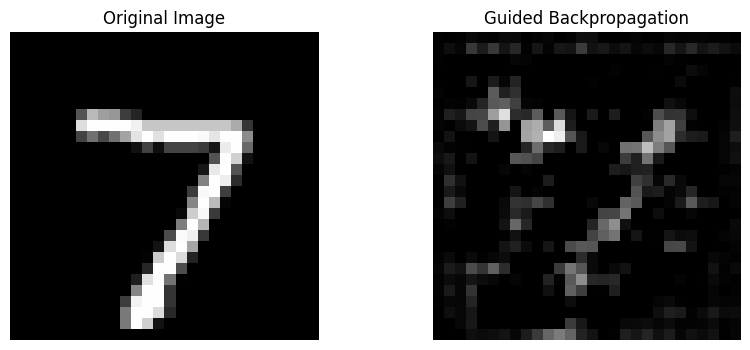

In [17]:
# Guided Backpropagation using CNN (Correct Version)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=10, batch_size=1500, validation_data=(X_test, Y_test))

input_img = X_test[0:1]
input_tensor = tf.convert_to_tensor(input_img)

# 5. Forward + Backward Pass
with tf.GradientTape() as tape:
    tape.watch(input_tensor)

    preds = model(input_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, input_tensor)

guided_grads = grads.numpy()
guided_grads[guided_grads < 0] = 0


guided_grads = guided_grads / (np.max(guided_grads) + 1e-8)


plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.imshow(input_img[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(guided_grads[0].reshape(28,28), cmap='gray')
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()
"""observation:

if you increase the no of epoches the then the image is not clear but the no of """

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9439 - loss: 0.1944 - val_accuracy: 0.9789 - val_loss: 0.0652
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9845 - loss: 0.0508 - val_accuracy: 0.9869 - val_loss: 0.0376
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9854 - val_loss: 0.0474
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9894 - val_loss: 0.0355
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9940 - loss: 0.0191 - val_accuracy: 0.9899 - val_loss: 0.0308
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 0.9902 - val_loss: 0.0291
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9896 - val_loss: 0.0335
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0

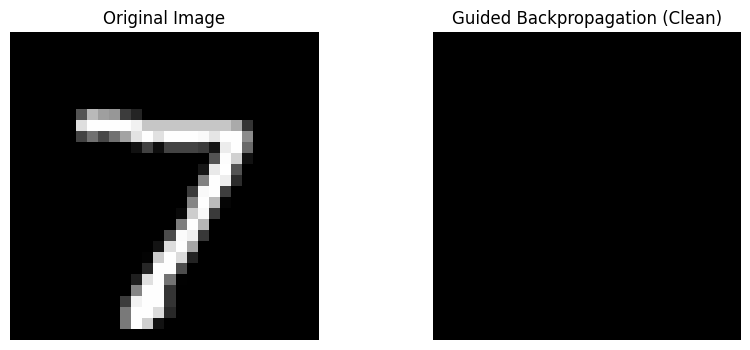

In [19]:
# Perfect Guided Backpropagation (Clean Output)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical

# 1. Load Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# 2. CNN Model
model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train
model.fit(X_train, Y_train, epochs=50, batch_size=128, validation_data=(X_test, Y_test))

# 4. Select Image
input_img = X_test[0:1]
input_tensor = tf.convert_to_tensor(input_img)

# 5. Gradient Calculation
with tf.GradientTape() as tape:
    tape.watch(input_tensor)

    preds = model(input_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, input_tensor)

# 6. 🔥 Improved Guided Backprop
guided_grads = grads.numpy()

# Step 1: Remove negative gradients (ReLU)
guided_grads[guided_grads < 0] = 0

# Step 2: Normalize
guided_grads = guided_grads / (np.max(guided_grads) + 1e-8)

# Step 3: Enhance important pixels
guided_grads = guided_grads ** 2

# Step 4: Threshold (remove background noise)
guided_grads[guided_grads < 0.2] = 0

# 7. Visualization
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(input_img[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(guided_grads[0].reshape(28,28), cmap='gray')
plt.title("Guided Backpropagation (Clean)")
plt.axis('off')

plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2761 - val_loss: 0.1902
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1710 - val_loss: 0.1533
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1438 - val_loss: 0.1330
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1280 - val_loss: 0.1208
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1178 - val_loss: 0.1124
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1108 - val_loss: 0.1067
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1059 - val_loss: 0.1026
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1023 - val_loss: 0.0994
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0996 - val_loss: 0.0972
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0976 - val_loss: 0.0956
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0963 - val_loss: 0.0945
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

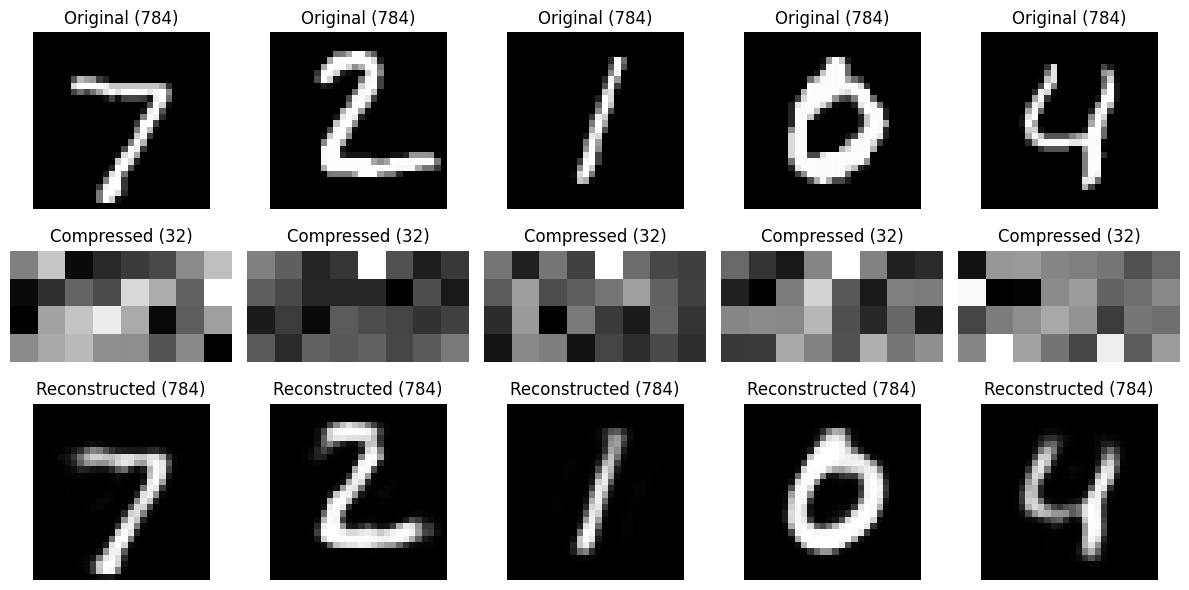

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten 28x28 → 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. Define Parameters
# -----------------------------
input_dim = 784
encoding_dim = 32  # compression

# -----------------------------
# 3. Encoder
# -----------------------------
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# -----------------------------
# 4. Decoder
# -----------------------------
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# -----------------------------
# 5. Models
# -----------------------------
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

# -----------------------------
# 6. Compile
# -----------------------------
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# -----------------------------
# 7. Train
# -----------------------------
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# -----------------------------
# 8. Predict
# -----------------------------
encoded_imgs = encoder.predict(x_test)        # 784 → 32
decoded_imgs = autoencoder.predict(x_test)    # 32 → 784

# -----------------------------
# 9. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original (784)")
    plt.gray()
    ax.axis('off')

    # Encoded (32 → 4x8)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(4, 8))
    plt.title("Compressed (32)")   # ✅ fixed label
    plt.gray()
    ax.axis('off')

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed (784)")
    plt.gray()
    ax.axis('off')

plt.tight_layout()   # ✅ better spacing
plt.show()

In [21]:
#Implementing Guided Backpropogation to find the pixel that activates the neuron

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense
from tensorflow.keras.models import Model

# -----------------------------
# 1. Load Image
# -----------------------------
img_path = "/content/dog-image.jfif"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# -----------------------------
# 2. Build CNN
# -----------------------------
inputs = Input(shape=(128,128,3))

x = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# -----------------------------
# 3. Choose target class
# -----------------------------
preds = model(img_array)
class_idx = tf.argmax(preds[0])

# -----------------------------
# 4. Guided Backpropagation
# -----------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# Replace ReLU with guided ReLU
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# -----------------------------
# 5. Compute Gradients
# -----------------------------
with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    tape.watch(inputs)
    preds = model(inputs)
    loss = preds[:, class_idx]

grads = tape.gradient(loss, inputs)[0]

# -----------------------------
# 6. Normalize gradients
# -----------------------------
grads = grads.numpy()

grads -= grads.mean()
grads /= (grads.std() + 1e-5)
grads *= 0.25

grads += 0.5
grads = np.clip(grads, 0, 1)

# -----------------------------
# 7. Display
# -----------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backpropagation")
plt.imshow(grads)
plt.axis('off')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/dog-image.jfif'


Training Autoencoder with dimension = 1024
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


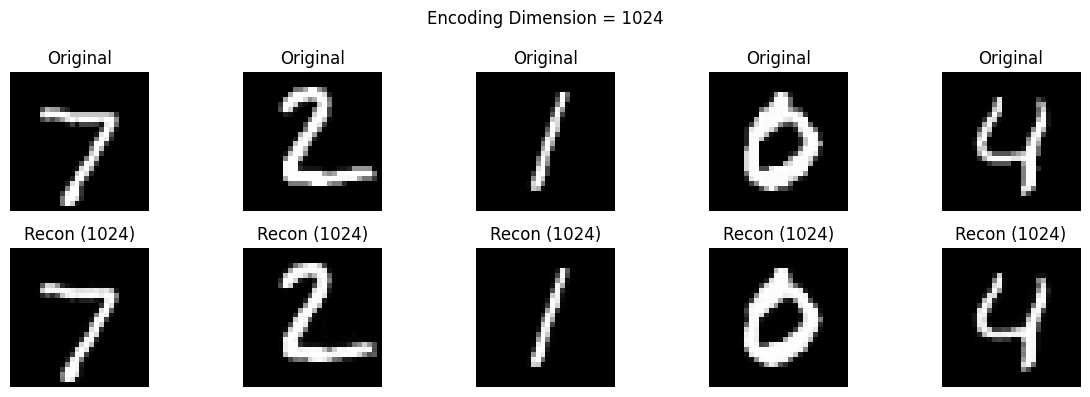


Training Autoencoder with dimension = 900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


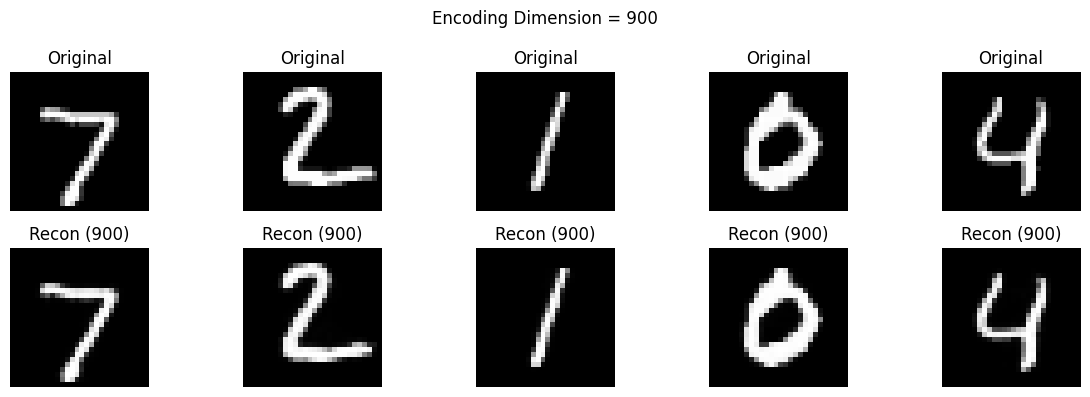


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


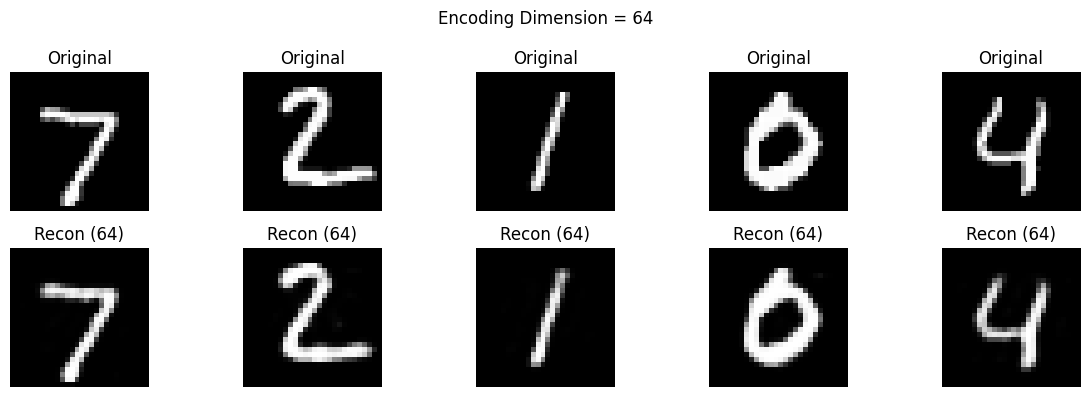


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


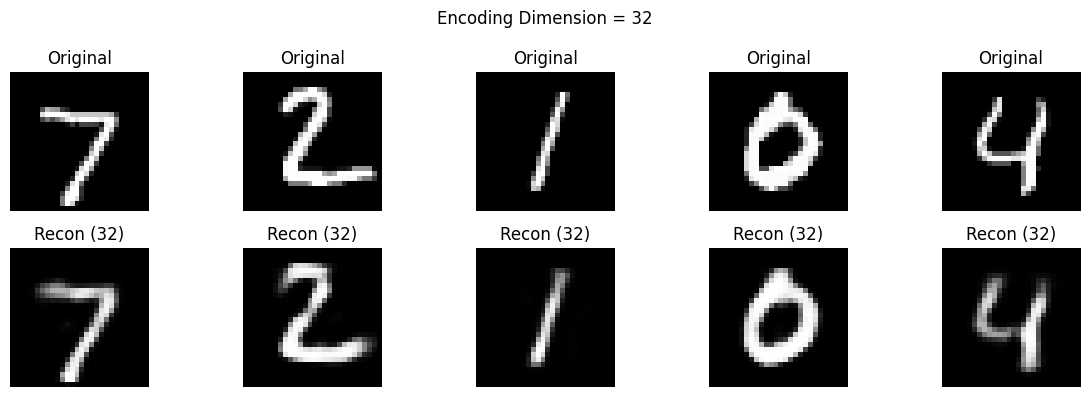


Training Autoencoder with dimension = 25
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


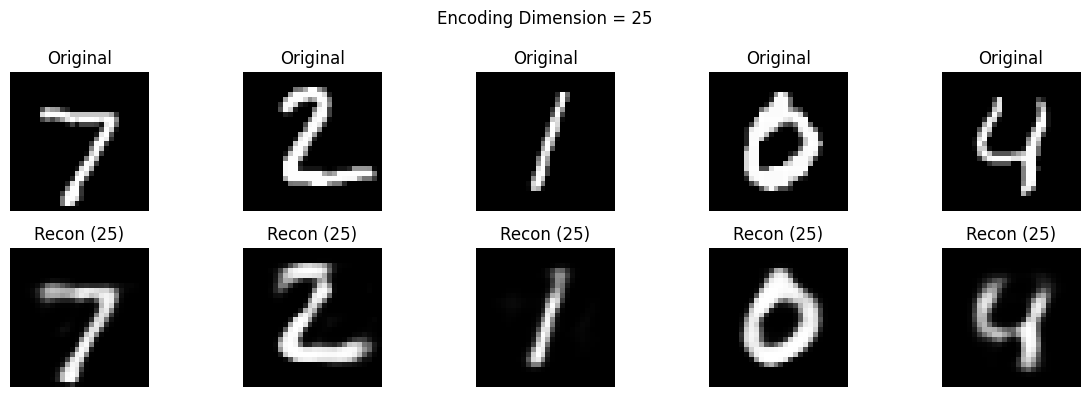


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


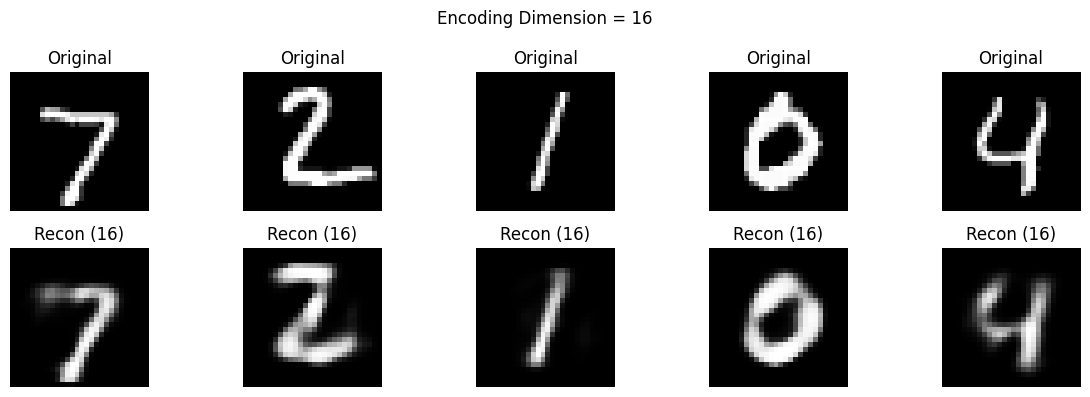


Training Autoencoder with dimension = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


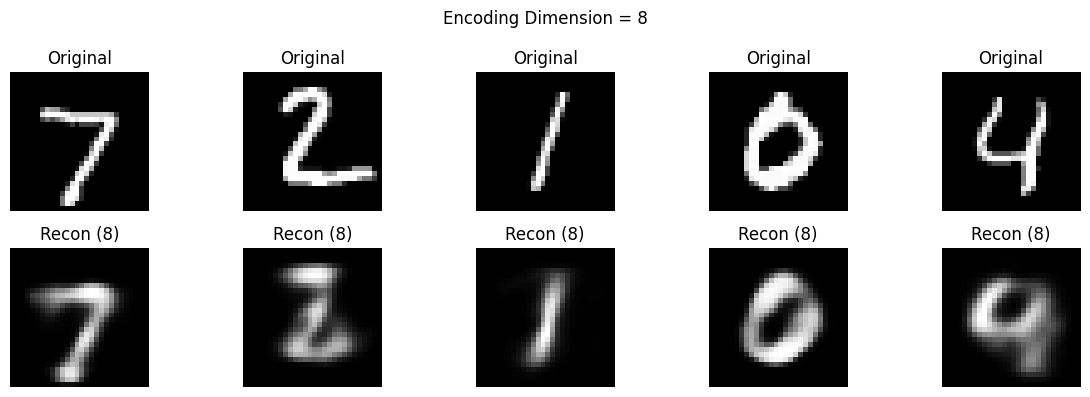


Training Autoencoder with dimension = 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


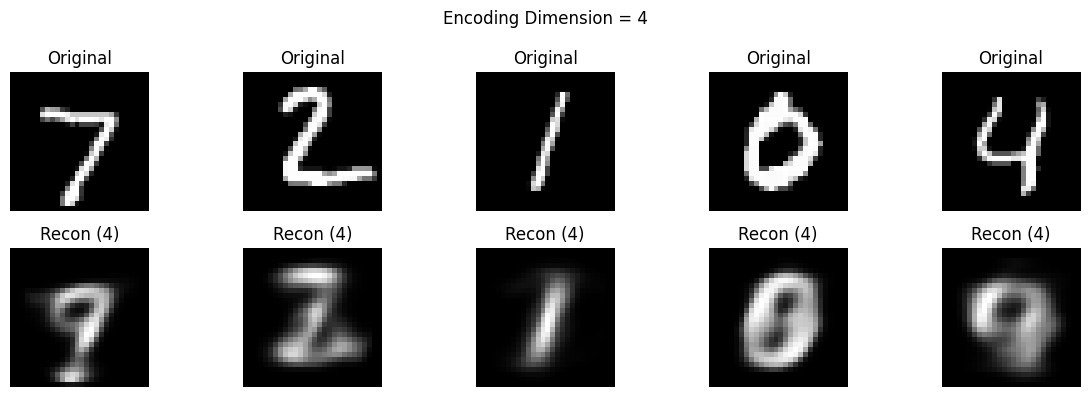


Training Autoencoder with dimension = 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


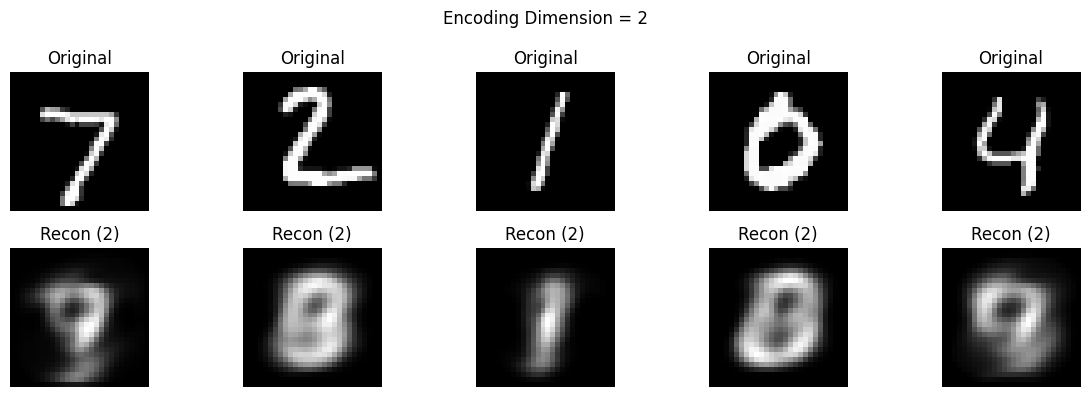


Training Autoencoder with dimension = 1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


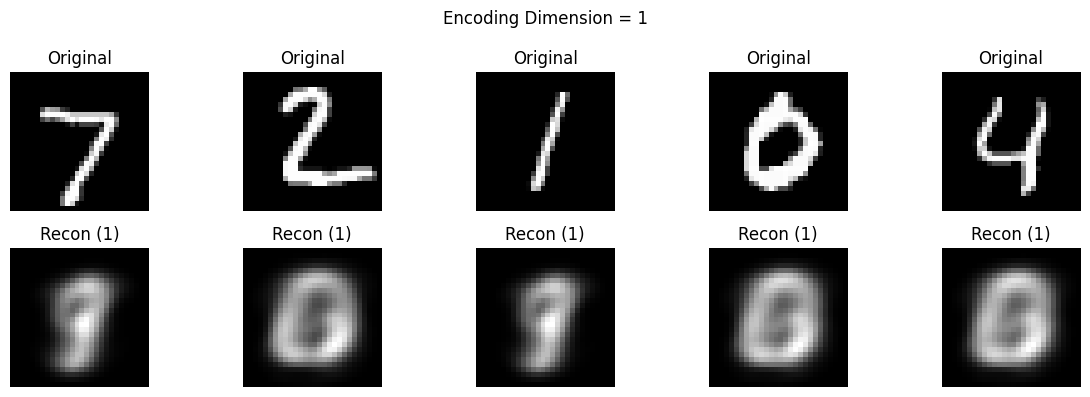

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


dimensions = [1024,900,64, 32, 25,16, 8, 4, 2, 1]


n = 5

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=50,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)


    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')


        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


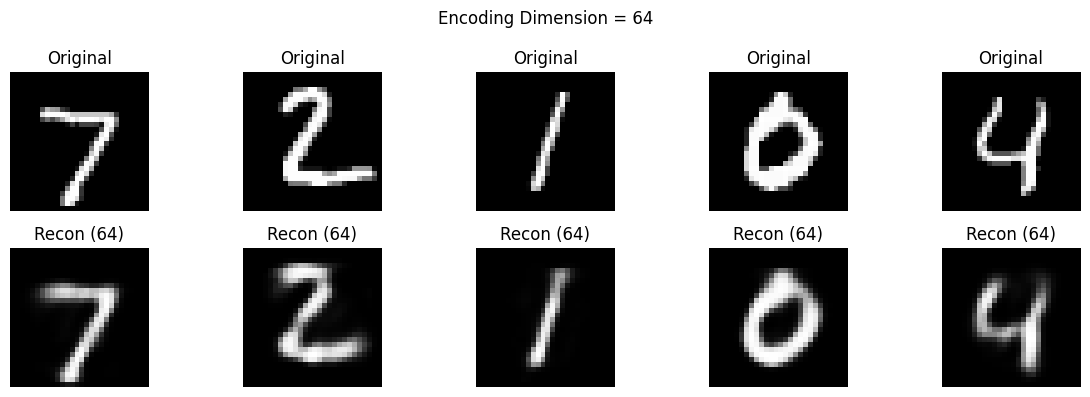


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


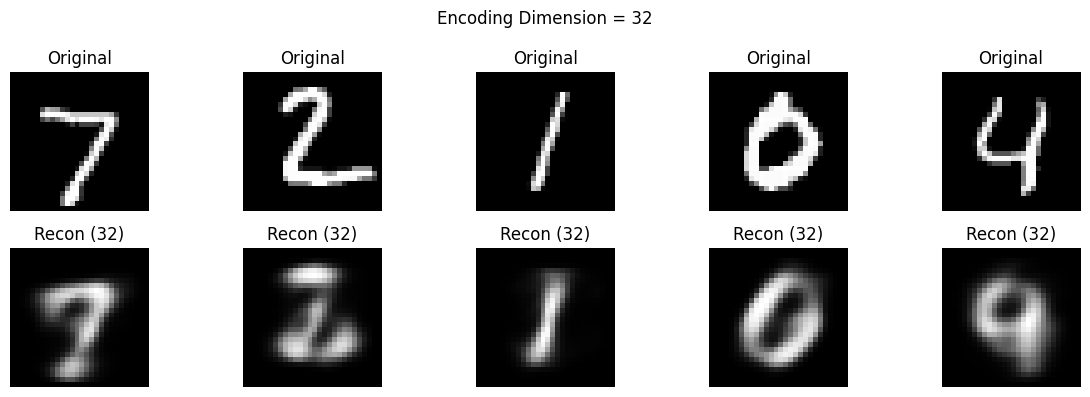


Training Autoencoder with dimension = 25
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


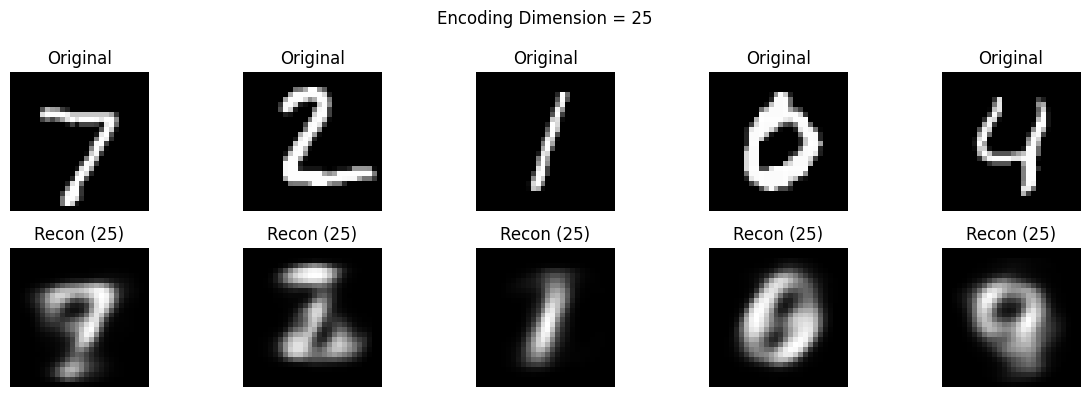


Training Autoencoder with dimension = 16


KeyboardInterrupt: 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


dimensions = [64, 32, 25,16, 8, 4, 2, 1]


n = 5

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=50,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)


    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')


        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


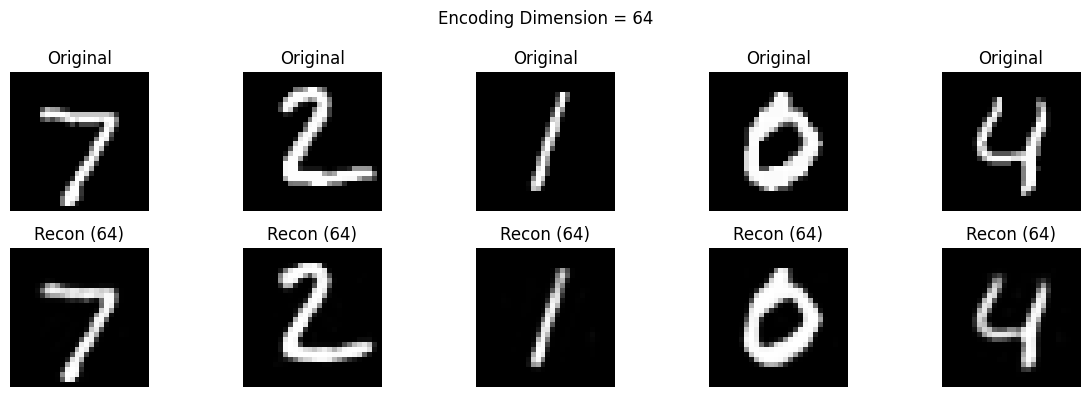


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


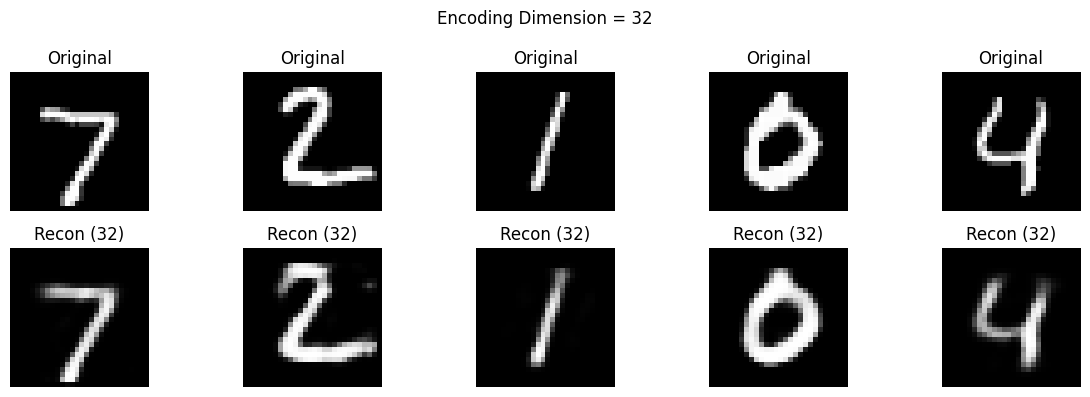


Training Autoencoder with dimension = 25
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


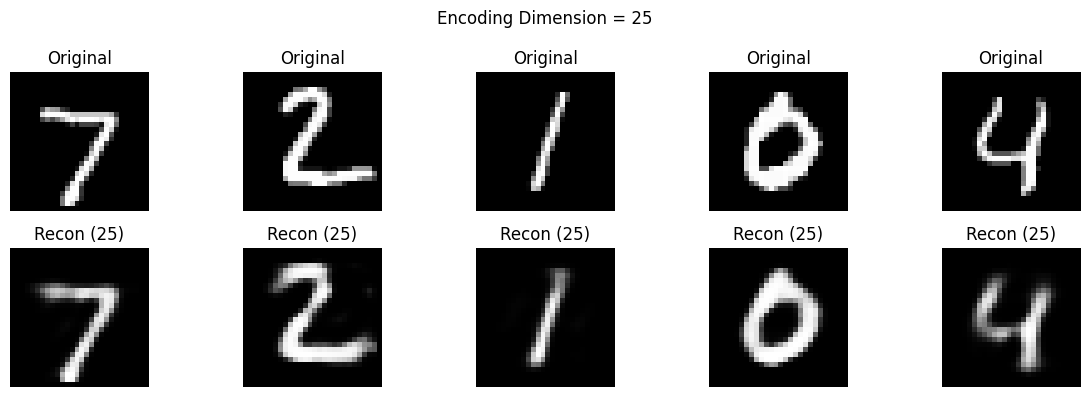


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


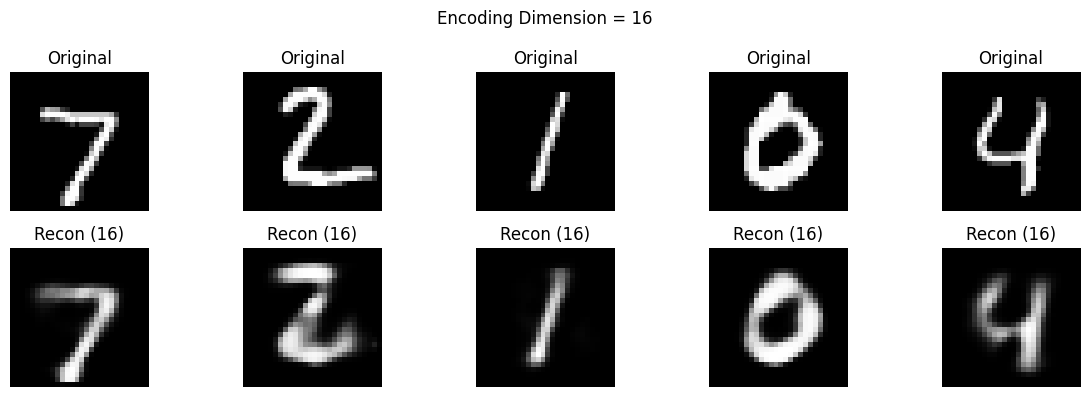


Training Autoencoder with dimension = 8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


dimensions = [64, 32, 25,16, 8, 4, 2, 1]


n = 5

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


    autoencoder.fit(x_train, x_train,
                    epochs=50,
                    batch_size=50,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)


    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')


        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()